In [ ]:
import pandas as pd

data_raw=pd.read_csv("Metro_Interstate_Traffic_Volume.csv")

# display 5 first records of dataset
print(data_raw.head())

  holiday    temp  rain_1h  snow_1h  clouds_all weather_main  \
0     NaN  288.28      0.0      0.0          40       Clouds   
1     NaN  289.36      0.0      0.0          75       Clouds   
2     NaN  289.58      0.0      0.0          90       Clouds   
3     NaN  290.13      0.0      0.0          90       Clouds   
4     NaN  291.14      0.0      0.0          75       Clouds   

  weather_description            date_time  traffic_volume  
0    scattered clouds  2012-10-02 09:00:00            5545  
1       broken clouds  2012-10-02 10:00:00            4516  
2     overcast clouds  2012-10-02 11:00:00            4767  
3     overcast clouds  2012-10-02 12:00:00            5026  
4       broken clouds  2012-10-02 13:00:00            4918  


In [ ]:
# Xem kieu du lieu cua cac cot
print(data_raw.dtypes)

holiday                 object
temp                   float64
rain_1h                float64
snow_1h                float64
clouds_all               int64
weather_main            object
weather_description     object
date_time               object
traffic_volume           int64
dtype: object


In [ ]:
# Thong ke so bo ve du lieu cua tung cot
display(data_raw.describe(include='all'))

,holiday,temp,rain_1h,snow_1h,clouds_all,weather_main,weather_description,date_time,traffic_volume
count,61,48204.000000,48204.000000,48204.000000,48204.000000,48204,48204,48204,48204.000000
unique,11,NaN,NaN,NaN,NaN,11,38,40575,NaN
top,Labor Day,NaN,NaN,NaN,NaN,Clouds,sky is clear,2013-05-19 10:00:00,NaN
freq,7,NaN,NaN,NaN,NaN,15164,11665,6,NaN
mean,NaN,281.205870,0.334264,0.000222,49.362231,NaN,NaN,NaN,3259.818355
std,NaN,13.338232,44.789133,0.008168,39.015750,NaN,NaN,NaN,1986.860670
min,NaN,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,0.000000
25%,NaN,272.160000,0.000000,0.000000,1.000000,NaN,NaN,NaN,1193.000000
50%,NaN,282.450000,0.000000,0.000000,64.000000,NaN,NaN,NaN,3380.000000
75%,NaN,291.806000,0.000000,0.000000,90.000000,NaN,NaN,NaN,4933.000000


In [ ]:
# --- NHAN XET BANG THONG KE DU LIEU (DESCRIPTIVE STATISTICS) ---
#
# 1. BIEN MUC TIEU (traffic_volume):
# - Tong so mau ghi nhan la 48.204 dong.
# - Luong xe trung binh moi gio qua tram dat ~3.260 xe.
# - Do lech chuan lon (1.986 xe) cho thay su bien dong cuc ky manh giua cac khung gio.
# - Luong xe cao nhat (max) len toi 7.280 xe/gio, thap nhat (min) la 0 xe/gio.
#
# 2. PHAT HIEN DU LIEU BAT THUONG (Outliers / Data Anomalies):
# - Cot nhiet do (temp): Gia tri min bang 0.00 Kelvin (-273.15 do C). Day la loi cam bien,
#   can phai loai bo hoac thay the o buoc lam sach du lieu.
# - Cot luong mua (rain_1h): Gia tri max len toi 9.831 mm/gio. Day la con so phi thuc te,
#   kha nang cao la nhieu do loi thiet bi do.
#
# 3. THONG TIN CAC BIEN PHAN LOAI (Categorical & Datetime):
# - Cot date_time: Co 40.575 moc gio duy nhat tren tong so 48.204 dong. Su chenh lech nay
#   chung minh co hien tuong trung lap dong (Duplicate Timestamps) do he thong ghi nhan
#   nhieu loai hinh thoi tiet khac nhau tai cung mot thoi diem.
# - Cot weather_main: Co 11 kieu thoi tiet duy nhat, trong do 'Clouds' (Nhieu may) la 
#   kieu thoi tiet chu dao xuat hien nhieu nhat (15.164 lan).
# - Cot holiday: Chi co 61 dong ghi nhan ngay le, pho bien nhat la 'Labor Day'.

In [ ]:
%pip install seaborn 


Note: you may need to restart the kernel to use updated packages.


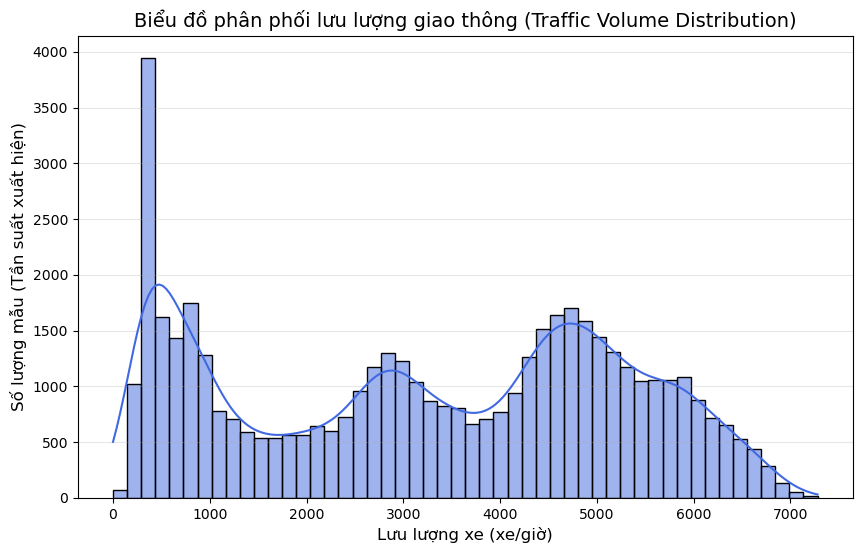

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# cau hinh kich thuoc bieu do
plt.figure(figsize=(10, 6))

# ve bieu do histogram cho cot 'traffic_volume'
sns.histplot(data=data_raw, x='traffic_volume', bins=50, kde=True, color='royalblue')
# them tieu de va nhan cho bieu do
plt.title('Biểu đồ phân phối lưu lượng giao thông (Traffic Volume Distribution)', fontsize=14)
plt.xlabel('Lưu lượng xe (xe/giờ)', fontsize=12)
plt.ylabel('Số lượng mẫu (Tần suất xuất hiện)', fontsize=12)

# hien thi bieu do
plt.grid(axis='y', alpha=0.3)
plt.show()

In [ ]:
# nhan xet ve bieu do tren:
# - bieu do nay cos 3 dinh, tuong ung voi 3 nhom luu luong giao thong: nho, trung binh va lon
# - nhom nho (dinh thu nhat): day la luong xe luu thong vao nua dem (~ 300-500 xe/h), chiem so luong mau cao nhat (max = ~4000 mau)
# - nhom trung binh (dinh thu hai): dai dien cho nhom thap diem ban ngay, mac du luong xe cao hon (~2500-3000 xe/h) nhung chiem so luong mau thap hon (max = ~2000 mau)
# - nhom lon (dinh thu ba): dai dien cho nhom cao diem ban ngay, luong xe cao nhat (~4000-5000 xe/h) nhung chiem so luong mau thap nhat (max = ~1000 mau)
# ngoai ra, bieu do con ghi nhan 1 so mau co luong xe cao (>6500 xe/h), dai dien cho nhung case ket xe, dieu nau the hien ro vao cac ngay le.

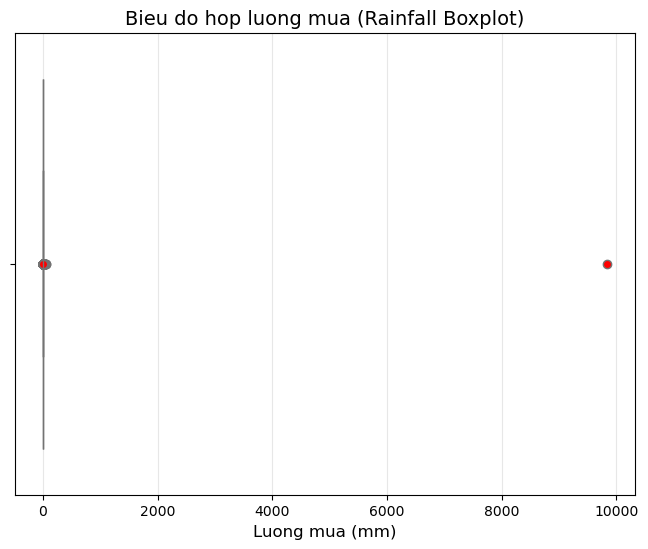

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Cau hinh kich thuoc bieu do
plt.figure(figsize=(8, 6))

# Ve bieu do Boxplot cho luu luong giao thong
# Dung tham so x= de ve hop nam ngang, giup de quan sat cac moc gia tri
#sns.boxplot(data=data_raw, x='traffic_volume', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})
#sns.boxplot(data=data_raw, x='temp', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})
sns.boxplot(data=data_raw, x='rain_1h', color='lightskyblue', flierprops={'markerfacecolor': 'red', 'marker': 'o'})

# Them tieu de va nhan truc
plt.title('Bieu do hop luong mua (Rainfall Boxplot)', fontsize=14)
plt.xlabel('Luong mua (mm)', fontsize=12)

# Hien thi bieu do
plt.grid(axis='x', alpha=0.3)
plt.show()

### QUY TRÌNH TIỀN XỬ LÝ DỮ LIỆU ĐỀ XUẤT (DATA PREPROCESSING)

**Mục tiêu:** Biến đổi tập dữ liệu thô thành tập dữ liệu chuỗi thời gian sạch, liên tục dưới dạng file `.csv` để huấn luyện mô hình.

1. **Lọc vùng dữ liệu ổn định:** Trích xuất phân đoạn dữ liệu liên tục từ năm 2017 đến 2018 nhằm đảm bảo tính toàn vẹn của chuỗi thời gian.
2. **Loại bỏ dữ liệu dị thường (Outliers):** - Xóa bỏ các dòng có nhiệt độ `temp = 0.00 K` (lỗi cảm biến).
   - Xóa bỏ các dòng có lượng mưa `rain_1h > 9.831 mm/h` (lỗi thiết bị đo).
3. **Xử lý trùng lặp thời gian:** Gom cụm (Groupby) các dòng có cùng mốc `date_time`. Tính giá trị trung bình (`mean`) cho các biến số và lấy giá trị phổ biến nhất (`mode`) cho các biến chữ.
4. **Xử lý mốc giờ bị khuyết (Missing Timestamps):** Tạo lại khung thời gian đầy đủ từng giờ và áp dụng phương pháp nội suy tuyến tính (`Linear Interpolation`) hoặc `Forward Fill` để điền đầy dữ liệu cho những giờ bị thiếu, giữ mạch thời gian liên tục thẳng tắp.
5. **Trích xuất đặc trưng (Feature Engineering):** Từ cột `date_time`, bóc tách thành các biến định lượng mới: `Hour` (Giờ trong ngày), `DayOfWeek` (Thứ trong tuần), `Month` (Tháng trong năm) và `Is_Weekend` (Có phải cuối tuần không) để mô hình học được quy luật sinh hoạt.
6. **Mã hóa biến phân loại (Encoding):** Chuyển đổi các cột dạng chữ như `weather_main` và `holiday` sang dạng số 0/1 bằng kỹ thuật `One-Hot Encoding`.
7. **Tạo biến trễ (Lag Features):** Tạo các cột giá trị quá khứ (`t-1`, `t-2`, `t-24`) trực tiếp trên biến mục tiêu `traffic_volume` để phục vụ cấu trúc thuật toán cửa sổ trượt (`Sliding Window`).
8. **Chuẩn hóa dữ liệu (Scaling):** Đưa dải dữ liệu về khoảng [0, 1] hoặc [-1, 1] để tối ưu tốc độ hội tụ và hiệu suất cho các thuật toán học máy.